# Pandas
**Topic:** Scientific Python

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


---
## What you'll explore

By the end of this demo you will be able to:

- **Load** a tabular dataset into a DataFrame and inspect its shape, dtypes, and summary statistics
- **Apply** filtering, sorting, and groupby operations to answer questions about the data
- **Interpret** method chaining as a pattern for building readable, step-by-step data transformations

---
## How we got here

In *13: NumPy* we learned that arrays are fast but require all data to be the same dtype and have no column labels. A DataFrame solves both problems: it is a collection of named NumPy arrays of potentially different dtypes, plus a row index. This is the data structure you will use for nearly all tabular data work in the course.

---
## Why this matters for data science

Pandas is the primary tool for every step between raw data and a scikit-learn model: loading, inspecting, cleaning, aggregating, and feature engineering. Knowing `groupby`, `merge`, `pivot_table`, and method chaining fluently will save you more time than almost any other skill in this course. Every Kaggle notebook, every industry EDA script, and every data science interview exercise is written in pandas.

---
## Try it yourself

In [9]:
# ▶ Run this cell and observe the output.
# Then try changing the values and running again.

import pandas as pd
from tkh_utils import load_titanic

df = load_titanic()

print(df.shape)
print(df.dtypes)
print(df.head(3))

(891, 15)
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  


In [10]:
# ✏️ Your turn — modify this code:
# 1. Change 'region' to 'category' in the groupby — what does the result look like?
# 2. Add .reset_index() at the end of the groupby chain and compare
# 3. What does df_sales.describe() show? Which columns appear?

import pandas as pd
import numpy as np
np.random.seed(14)

df_sales = pd.DataFrame({
    'region':   np.random.choice(['North', 'South', 'East', 'West'], 200),
    'revenue':  np.random.lognormal(5, 0.4, 200).round(2),
    'units':    np.random.randint(1, 10, 200),
})

summary = df_sales.groupby('region')['revenue'].agg(['mean', 'sum', 'count']).round(2)
print(summary)

          mean      sum  count
region                        
East    148.65  6838.12     46
North   148.95  7447.74     50
South   150.55  7828.64     52
West    145.84  7583.61     52


In [11]:
# 🎯 Challenge:
# Using the Titanic dataset:
#   1. Find the survival rate (mean of 'survived') grouped by 'pclass' AND 'sex' combined
#   2. Identify how many passengers have a missing 'age' value
#   3. Fill missing ages with the median age for that passenger class
# Hint: use groupby() with a list of columns, .isna().sum(), and .transform('median')

import pandas as pd
from tkh_utils import load_titanic

df = load_titanic()

# Your code here:

---
## What's happening?

A DataFrame is an indexed, labeled, column-oriented table. The two most important methods for understanding a new dataset are `df.head()` and `df.info()`. The three most important methods for answering questions about it are `groupby`, `merge`, and `pivot_table`.

| Operation | Syntax | What it does |
|-----------|--------|-------------|
| Load | `pd.read_csv("file.csv")` | Read a CSV into a DataFrame |
| Inspect | `df.info()`, `df.describe()` | Dtypes, missing counts, summary stats |
| Filter rows | `df[df["age"] > 30]` | Boolean indexing |
| Select columns | `df[["name", "salary"]]` | Subset of columns |
| Group & aggregate | `df.groupby("dept")["salary"].mean()` | Mean salary per department |
| Sort | `df.sort_values("salary", ascending=False)` | Order rows by a column |
| Method chain | `(df.query("active").groupby("dept")["salary"].mean().sort_values())` | Three steps, one expression |

```python
# The canonical EDA pipeline in 5 chained methods
summary = (
    df
    .query("tenure_yrs >= 1")
    .assign(salary_k=lambda d: d["salary"] / 1000)
    .groupby("department")["salary_k"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
    .round(1)
)
```

### `groupby` is a split-apply-combine operation

`df.groupby("dept")` splits the DataFrame into one sub-DataFrame per department. Calling `.mean()` applies the mean to each sub-DataFrame. The results are combined back into a single Series. The chart in the widget is this output.

Return to the widget and switch between `mean` and `count` to see how the same groupby key produces very different aggregations.

---
## A direct example: one groupby, one question answered

Seven rows, three departments. `groupby` splits the DataFrame by department, `.mean()` computes the average salary for each group, and the chart shows the result.

- **Notice:** `groupby` does not change any data — it splits the DataFrame into sub-groups, applies the aggregation, then combines the results
- **Notice:** `.sort_values()` at the end orders the bars — `groupby` itself returns groups in alphabetical key order
- **Notice:** This same one-liner works on a 7-row DataFrame or a 7-million-row one

dept
HR       61000.0
Sales    70000.0
Eng      95000.0
Name: salary, dtype: float64


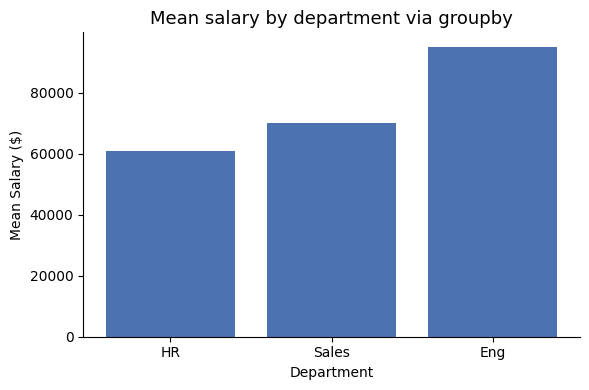

In [12]:
df = pd.DataFrame({
    "dept":   ["Sales", "Sales", "Eng", "Eng", "Eng", "HR", "HR"],
    "salary": [62_000, 78_000, 95_000, 88_000, 102_000, 58_000, 64_000],
})

mean_salary = df.groupby("dept")["salary"].mean().sort_values()
print(mean_salary)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(mean_salary.index, mean_salary.values, color="#4C72B0")
ax.set_title("Mean salary by department via groupby", fontsize=13)
ax.set_xlabel("Department")
ax.set_ylabel("Mean Salary ($)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

---
## Real-world example: Regional sales performance analysis

The chart below applies a `groupby` + `agg` pipeline to a simulated retail sales dataset with 500 transactions across 4 regions and 3 product categories. This is the exact type of EDA a business analyst or data scientist would run on their first day with a new sales dataset.

Notice:

- **Notice:** The `groupby` groups on two columns simultaneously (`region` and `category`), producing a multi-level index that the chart flattens for display
- **Notice:** Total revenue varies dramatically by region even within the same category, which would prompt further investigation into pricing, inventory, or market size differences
- **Notice:** The `.agg()` call computes multiple statistics in one pass over the data, which is more efficient than three separate `.groupby().mean()` calls

> **Discussion question:** The chart shows that the West region leads in electronics revenue. Before concluding that the West team is more effective, what confounding variables would you want to check in the data?

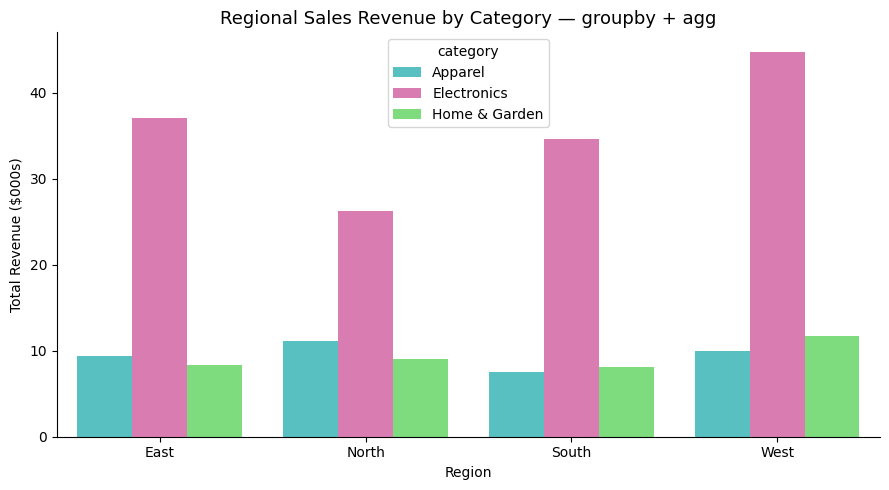

In [14]:
np.random.seed(14)

# ── Regional sales analysis via groupby ──────────────────────────────────────
n          = 500
regions    = np.random.choice(["North", "South", "East", "West"], n)
categories = np.random.choice(["Electronics", "Apparel", "Home & Garden"], n,
                               p=[0.35, 0.40, 0.25])
base_prices = {"Electronics": 280, "Apparel": 65, "Home & Garden": 95}
prices  = np.array([base_prices[c] * np.random.lognormal(0, 0.3) for c in categories])
units   = np.random.randint(1, 6, n)
revenue = prices * units

df_sales = pd.DataFrame({
    "region": regions, "category": categories,
    "unit_price": prices.round(2), "units": units,
    "revenue": revenue.round(2),
})

summary = (
    df_sales
    .groupby(["region", "category"])["revenue"]
    .sum()
    .reset_index()
)
summary["revenue_k"] = summary["revenue"] / 1000

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=summary, x="region", y="revenue_k", hue="category",
            palette=["#47D1D1", "#E76DB4", "#6EEC6E"], ax=ax)
ax.set_title("Regional Sales Revenue by Category — groupby + agg", fontsize=13)
ax.set_xlabel("Region")
ax.set_ylabel("Total Revenue ($000s)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


### Essential pandas operations for data science

| Task | Code | Notes |
|------|------|-------|
| Load CSV | `pd.read_csv(path, parse_dates=["date"])` | Parse dates at load time |
| Quick overview | `df.describe(include="all")` | Stats for numeric and categorical columns |
| Count missing | `df.isna().sum()` | Per-column missing value count |
| Filter + select | `df.loc[df["a"] > 0, ["a", "b"]]` | Row filter with column selection |
| Add a column | `df["new"] = df["a"] + df["b"]` | In-place column addition |
| Merge two tables | `pd.merge(df1, df2, on="id", how="left")` | SQL-style left join |
| Reshape wide to long | `df.melt(id_vars=["id"], value_vars=["q1", "q2"])` | Tidy format for plotting |

---
## Key takeaway

> **A DataFrame is a labeled, column-oriented table of NumPy arrays; groupby, merge, and method chaining are the three operations that cover the vast majority of real-world data manipulation tasks.**

---
*Next up: Data Cleaning — the systematic process of identifying and fixing the quality problems that live in almost every real-world dataset before modeling begins*